## LAB 2: LINEAR REGRESSION

## Bal Krishna Dhakal(ACE080BCT018)

Task: Simple Linear Regression 

Input Feature: YearsExperience

Label: Salary


1️⃣ Data Retrieval and Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
     

In [2]:
df = pd.read_csv('Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [3]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='str')

In [4]:


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [5]:
print(df.shape)

(30, 2)


In [6]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000



2️⃣ Data Cleaning

In [7]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

Observation: There is no missing values
Missing value treatement:
Since there is no missing values in the selected feature(YearsExperience), no treatement is required. if there were missing values present, we would have handle using:

In [8]:
df['YearsExperience'].fillna(df['YearsExperience'].mean(), inplace=True)

0      1.1
1      1.3
2      1.5
3      2.0
4      2.2
5      2.9
6      3.0
7      3.2
8      3.2
9      3.7
10     3.9
11     4.0
12     4.0
13     4.1
14     4.5
15     4.9
16     5.1
17     5.3
18     5.9
19     6.0
20     6.8
21     7.1
22     7.9
23     8.2
24     8.7
25     9.0
26     9.5
27     9.6
28    10.3
29    10.5
Name: YearsExperience, dtype: float64

In [9]:

df.dtypes

YearsExperience    float64
Salary               int64
dtype: object

3️⃣ Feature Design

In [10]:
X = df[['YearsExperience']]
y = df['Salary']

The feature YearsExperience was selected because it has a strong relationship with Salary. In most real-world cases, salary tends to increase as work experience increases.

Employees with higher years of experience generally receive higher salaries.
Employees with less experience usually have lower salaries.

Therefore, YearsExperience is an appropriate and meaningful feature for building a single-feature linear regression model to predict salary.

4️⃣Algorithm Selection: Linear Regression

Linear Regression is chosen because the goal of this task is to predict a continuous numerical value (Salary).

In this case, only one input variable (YearsExperience) is used, which makes it a simple linear regression problem.

Linear Regression works by finding the best-fitting straight line that represents the relationship between the input feature and the target variable. It helps in understanding how changes in experience affect salary.

Thus, Linear Regression is a suitable and effective algorithm for this prediction task.

5️⃣ Loss Function Selection: Mean Squared Error (MSE)

Mean Squared Error (MSE) is used as the loss function to measure model performance.

It calculates the average of the squared differences between actual and predicted values.

Why MSE is used?
* It ensures all error values are positive by squaring them.
* Larger errors are penalized more than smaller ones.
* It provides a clear and standard way to measure model accuracy.
* A lower MSE value means better model performance, as predictions are closer to actual values.


6️⃣ Model Learning (Training)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
     

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


Learning Process

During the training phase, the Linear Regression model learns the relationship between Years of Experience and Salary by finding the best-fitting straight line.

The model adjusts its parameters (slope and intercept) in such a way that the difference between the actual salary values and predicted salary values becomes as small as possible.

In this process, the model uses the Least Squares approach, which is closely related to minimizing the prediction error.

However, in this assignment, the performance of the model is evaluated using Mean Squared Error (MSE). MSE measures the average squared difference between actual and predicted values, helping to quantify how well the model is performing.

A lower MSE value indicates that the model has learned the data more accurately and provides better predictions.

7️⃣ Model Evaluation

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 49830096.85590839
R² Score: 0.9024461774180497


In [14]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 7059.04362190151


Model Evaluation Results

Mean Squared Error (MSE):

The Mean Squared Error (MSE) obtained was 49,830,096.86, which corresponds to a Root Mean Squared Error (RMSE) of approximately 7,059.

This indicates that, on average, the model’s salary predictions deviate from the actual values by around 7,059 units. This level of error shows that the model has a reasonable predictive ability, though some variation still exists between predicted and actual salaries.

R² Score:

The Linear Regression model achieved an R² score of 0.9024, meaning that approximately 90.24% of the variation in salary is explained by the feature Years of Experience.

This high R² value suggests that the model fits the data well and effectively captures the relationship between experience and salary.

In [15]:
print("Intercept:",model.intercept_)
print("Coefficient:",model.coef_)

Intercept: 25321.583011776813
Coefficient: [9423.81532303]


Model Interpretation

Coefficient (Slope): 9423.81
Intercept: 25321.6

What does the coefficient represent?
The coefficient (also called the slope) represents the change in the predicted salary for each additional unit increase in years of experience.

In this model, it means that for every additional year of experience, the salary is expected to increase by approximately 9,423.81 units, assuming all other factors remain constant.

This shows a positive relationship between experience and salary.

What does the intercept mean?
The intercept represents the predicted salary when the value of Years of Experience is zero.

In this case, the model predicts that a person with 0 years of experience would have a salary of approximately 25,321.6 units.

This value acts as the starting point of the regression line.

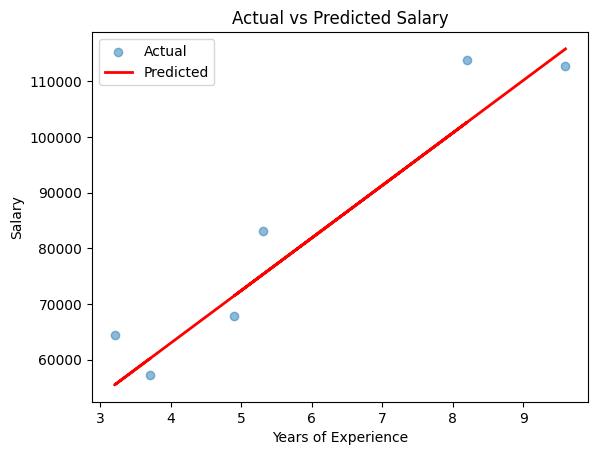

In [16]:
plt.scatter(X_test, y_test, label="Actual", alpha=0.5)
plt.plot(X_test, y_pred, color='red', label="Predicted", linewidth=2)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.show()

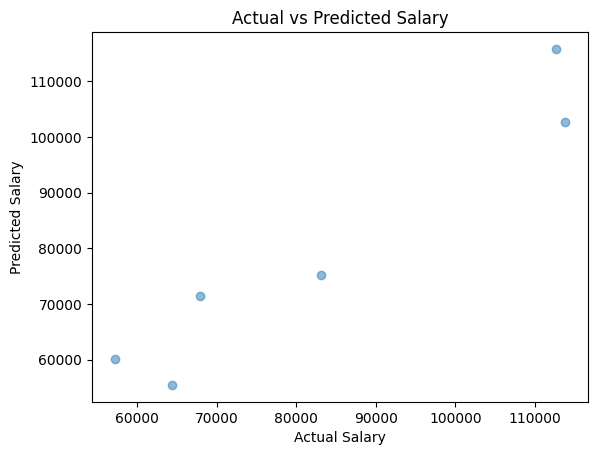

In [17]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

Single vs Multi Feature Comparison

* Single Feature Model
  Simple and highly interpretable
  Easy to visualize
  Limited predictive capability
  Ignores other influencing factors

* Multi Feature Model
  More complex but powerful
  Captures relationships between multiple variables
  Higher accuracy and better generalization
  Less interpretable

This comparison highlights the trade-off between interpretability and performance in machine learning.

Discussion

The Linear Regression model was developed to analyze and quantify the relationship between Years of Experience and Salary. The results demonstrate a strong positive linear relationship between the independent variable (experience) and the dependent variable (salary), indicating that salary generally increases with increasing work experience.

The model achieved an R² score of 0.9024, which implies that approximately 90.24% of the variance in salary is explained by years of experience. This high R² value suggests that the model fits the data well and that experience is a dominant predictor of salary variation in the dataset. However, the remaining unexplained variance (around 9.76%) indicates that other factors such as skills, education, job role, and industry type may also influence salary but are not included in the model.

The Mean Squared Error (MSE) of 49,830,096.86 and the corresponding RMSE of approximately 7,059 indicate that, on average, the model’s predictions deviate from actual salary values by about 7,059 units. While this error reflects some level of prediction inaccuracy, it is reasonably acceptable given the simplicity of the single-feature linear regression model.

Furthermore, the positive regression coefficient confirms a direct relationship between experience and salary. Specifically, it shows that salary increases consistently with each additional year of experience, reinforcing the economic and real-world expectation of experience-based compensation growth.

Overall, the model demonstrates strong predictive capability for a simple linear regression system. However, its limitations highlight that salary determination is a multifactorial problem, and incorporating additional relevant features could further improve predictive accuracy and model robustness.